# Simulate Populations with Spontaneus Birth
## Part 6

Previously we delved into survival analysis and ended up with a function that enables us to accuratley predict the distribution of population age given a constant and independed `death_chance`. Let's see if we can do the same for calculating the population growth. Let's first see if we can simplify the model we created in part 1 to just an equation with which we can reach the answer numerically. 

### Calculate Population Recursively

We want to know the population $P$ at the current time step $t$. If we know the population at the end of the previous time step, $P_{t-1}$, then the population that will survive the current time step is $P_{t-1}(1-d)$ where $d$ is the chance of death. The population increases by $B$ protocells each period (we will assume it always survives the first period). The full recursive function is then as follows:

$$P_t=P_{t-1}(1-d)+B$$

Note that this equation requires feeding in the value of the previous iteration $P_{t-1}$, making this a recursive function. To know what the population is after $n$ time steps, we need to know the initial population $P_{t=0}$ and then recursively recalculate $P_t$ for $n$ periods. We cannot determine $P$ immediately.

Let's calculate the solutions for various starting populations for 100 periods and see what it looks like on a graph.

In [13]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.ticker as ticker
from fractions import Fraction
import random

In [14]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
n_periods = 100

In [15]:
def recursive_pop(birth_rate, death_chance, pop, n_periods):
    ''' Recursive function for popualtion growth with contstant birth rate and
        independent death chance'''

    p_function = [pop] #pop_0 is first item, the function returns
    for t in range(0,n_periods): #pop_t+1 for any t.
        pop = pop*(1-death_chance)+birth_rate
        p_function.append(pop)
    return p_function

def pop_equilib(birth_rate, death_chance):
    ''' Calculate the population equilibrium for population with constant birth rate
        and independent death chance'''

    return birth_rate/death_chance

We will first show a table comparing the population over time for different starting populations. The rows are time step and the column headers inform of the starting population.

In [16]:
import pandas as pd

def generate_table(function, birth_rate, death_rate, n_rows, n_cols, col_tag="col"):
    """ Generate a table with rows from 0 to n_rows and columns from 0 to n_cols
        where function(birth_rate, death_chance, starting_pop=col, n_periods=n_rows 
        is applied to each column"""

    df = pd.DataFrame()
    for col in range(n_cols):
        col_name = f"{col_tag}_{col}"
        df[col_name] = function(birth_rate, death_chance, col, n_rows)
    return df

df = generate_table(recursive_pop, birth_rate, death_chance, 25, 20, "Pop")
df

,Pop_0,Pop_1,Pop_2,Pop_3,Pop_4,Pop_5,Pop_6,Pop_7,Pop_8,Pop_9,Pop_10,Pop_11,Pop_12,Pop_13,Pop_14,Pop_15,Pop_16,Pop_17,Pop_18,Pop_19
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.0,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000,18.000000,19.000000
1,1.000000,1.900000,2.800000,3.700000,4.600000,5.500000,6.400000,7.300000,8.200000,9.100000,10.0,10.900000,11.800000,12.700000,13.600000,14.500000,15.400000,16.300000,17.200000,18.100000
2,1.900000,2.710000,3.520000,4.330000,5.140000,5.950000,6.760000,7.570000,8.380000,9.190000,10.0,10.810000,11.620000,12.430000,13.240000,14.050000,14.860000,15.670000,16.480000,17.290000
3,2.710000,3.439000,4.168000,4.897000,5.626000,6.355000,7.084000,7.813000,8.542000,9.271000,10.0,10.729000,11.458000,12.187000,12.916000,13.645000,14.374000,15.103000,15.832000,16.561000
4,3.439000,4.095100,4.751200,5.407300,6.063400,6.719500,7.375600,8.031700,8.687800,9.343900,10.0,10.656100,11.312200,11.968300,12.624400,13.280500,13.936600,14.592700,15.248800,15.904900
5,4.095100,4.685590,5.276080,5.866570,6.457060,7.047550,7.638040,8.228530,8.819020,9.409510,10.0,10.590490,11.180980,11.771470,12.361960,12.952450,13.542940,14.133430,14.723920,15.314410
6,4.685590,5.217031,5.748472,6.279913,6.811354,7.342795,7.874236,8.405677,8.937118,9.468559,10.0,10.531441,11.062882,11.594323,12.125764,12.657205,13.188646,13.720087,14.251528,14.782969
7,5.217031,5.695328,6.173625,6.651922,7.130219,7.608516,8.086812,8.565109,9.043406,9.521703,10.0,10.478297,10.956594,11.434891,11.913188,12.391485,12.869781,13.348078,13.826375,14.304672
8,5.695328,6.125795,6.556262,6.986730,7.417197,7.847664,8.278131,8.708598,9.139066,9.569533,10.0,10.430467,10.860934,11.291402,11.721869,12.152336,12.582803,13.013270,13.443738,13.874205
9,6.125795,6.513216,6.900636,7.288057,7.675477,8.062898,8.450318,8.837739,9.225159,9.612580,10.0,10.387420,10.774841,11.162261,11.549682,11.937102,12.324523,12.711943,13.099364,13.486784


Let's see what this looks like graphed out.

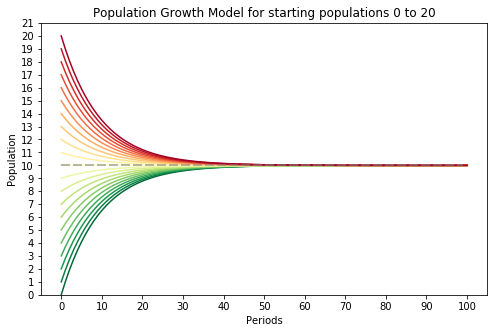

In [17]:
# Plot lines from 0 to 15 with gradient color black to light grey
def plot_pop_growth(n_periods, birth_rate, death_chance, pop_range_min, pop_range_max):
    ''' Plot population growth for starting populations in range plot_pop_range'''
    
    # Calculate population equilibrium (plot equilibrum line)
    pop_eq = pop_equilib(birth_rate, death_chance)

    # Set up figure.
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Growth Model for starting populations {pop_range_min} to {pop_range_max-1}",
        xlabel="Periods",
        ylabel="Population",
    )
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    #Set the range of y-limit based on graphed pop. ranges & always show pop. equilibrium.
    ax.set_ylim(
        pop_eq -1 if pop_eq < pop_range_min else pop_range_min, 
        pop_eq + 1 if pop_eq > pop_range_max else pop_range_max
        )

    # Set colormap (green to red).
    cmap = plt.get_cmap('RdYlGn_r')

    # Add population growth lines for starting populations in specified range.
    for pop0 in range(pop_range_min, pop_range_max):

        p_function = recursive_pop(birth_rate, death_chance, pop0, n_periods,)
        #pop0/(pop_eq*2) ensures positive growth is plotted green, negative growth is plotted red.
        ax.plot(range(0, n_periods+1), p_function, color=cmap(pop0/(pop_eq*2)))

    ax.plot(
        range(0, n_periods),
        [pop_eq for i in range(0, n_periods)],
        color='grey',
        alpha=0.75,
        dashes=[6, 2]
        )
    
    plt.show()

plot_pop_growth(n_periods, birth_rate,death_chance, 0, 21)

As you can see, when the starting population is below 10, the population increases towards 10 and then levels off, never surpassing 10. Similarily, when the starting population is above 10, the population decreases until it reaches 10 and then stabilizes.

Let's see how this model compares to the simulation from part 2 (the simulation below is taken from part 2, the plotting function is updated to show the result of our model for population growth, and we add a `starting_pop` parameter to `environment` so that we can vary the population size at the start of the simulation):

In [32]:
import random
import collections

def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance, starting_pop):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = [entity() for p in range(0, starting_pop)]
        self.history = [starting_pop]
        self.mortuary = collections.Counter()

    def __call__(self):
        survive, expire = [], []
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e.period) 
            else:
                survive.append(e())
        
        self.population = survive + (self.birth_rate * [entity()])
        self.mortuary.update(expire)
        self.history.append(len(self.population))

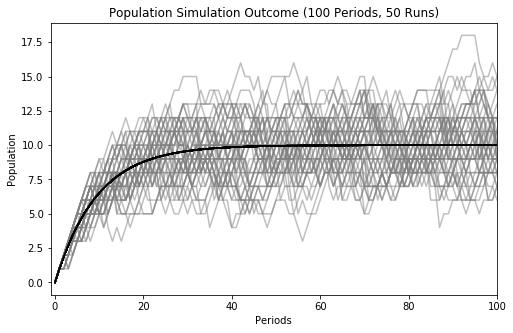

In [33]:
def run_sim(birth_rate, death_chance, starting_pop, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(-1, n_periods),
    )

    # Run numerical model (simulation simplified by recursive function) 
    p_function = recursive_pop(birth_rate, death_chance, 0, n_periods)

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        env = environment(birth_rate, death_chance, starting_pop)
        for period in range(0, n_periods+1):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])
        ax.plot(range(0, n_periods+1), p_function, color='k')

# Run the simulation
run_sim(birth_rate, death_chance, 0, 100, 50)

### Conclusion

The model matches perfectly and shows the expected (average) population at each time step.